# Part 1: Deep Exploratory Analysis & Feature Engineering
**Name:** Areeba Amjad

## Objectives:
- Explore and understand the Steel Industry Energy Consumption dataset.
- Assess the dataset for data quality issues such as missing values, duplicates, and outliers.
- Engineer new features from the existing data to enrich the dataset.
- Analyze relationships between variables using visualizations and correlation analysis.
- Identify key patterns and insights that influence energy consumption.

## Dataset Information
The Steel Industry Energy Consumption dataset contains real electricity usage records collected from a steel manufacturing plant. It includes energy consumption, load types, power factors, CO₂ emissions, and timestamp information for analyzing industrial energy usage.

## Importing Libraries

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Loading the Dataset

In [19]:
ds= pd.read_excel("C:/Users/Laptop Zone/OneDrive/Desktop/Steel_industry_data.xlsx")
ds.head()

,date,Usage_kWh,Lagging_Current_Reactive.Power_kVarh,Leading_Current_Reactive_Power_kVarh,CO2(tCO2),Lagging_Current_Power_Factor,Leading_Current_Power_Factor,NSM,WeekStatus,Day_of_week,Load_Type
0,2018-01-01 00:15:00,3.17,2.95,0.0,0.0,73.21,100.0,900,Weekday,Monday,Light_Load
1,2018-01-01 00:30:00,4.00,4.46,0.0,0.0,66.77,100.0,1800,Weekday,Monday,Light_Load
2,2018-01-01 00:45:00,3.24,3.28,0.0,0.0,70.28,100.0,2700,Weekday,Monday,Light_Load
3,2018-01-01 01:00:00,3.31,3.56,0.0,0.0,68.09,100.0,3600,Weekday,Monday,Light_Load
4,2018-01-01 01:15:00,3.82,4.50,0.0,0.0,64.72,100.0,4500,Weekday,Monday,Light_Load


## Dataset Structure

**Dataset Information**

In [20]:
print("====================Information:======================") 
ds.info()

====================Information:======================
<class 'pandas.DataFrame'>
RangeIndex: 35040 entries, 0 to 35039
Data columns (total 11 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   date                                  35040 non-null  object 
 1   Usage_kWh                             35040 non-null  float64
 2   Lagging_Current_Reactive.Power_kVarh  35040 non-null  float64
 3   Leading_Current_Reactive_Power_kVarh  35040 non-null  float64
 4   CO2(tCO2)                             35040 non-null  float64
 5   Lagging_Current_Power_Factor          35040 non-null  float64
 6   Leading_Current_Power_Factor          35040 non-null  float64
 7   NSM                                   35040 non-null  int64  
 8   WeekStatus                            35040 non-null  str    
 9   Day_of_week                           35040 non-null  str    
 10  Load_Type                             

**Dataset Overview Table**

In [21]:
overview = pd.DataFrame({
    "Property":[
        "Number of Rows",
        "Number of Columns",
        "Numerical Features",
        "Categorical Features",
        "Missing Values",
        "Duplicate Records",
        "Estimated Memory Usage",
    ],
    "Value":[
        int(ds.shape[0]),
        int(ds.shape[1]),
        len(ds.select_dtypes(include="number").columns),
        len(ds.select_dtypes(include=["object", "string"]).columns),
        int(ds.isnull().sum().sum()),
        int(ds.duplicated().sum()),
        "2.9+ MB"
    ]
})
overview.style.set_properties(subset=["Property"], **{"text-align": "left"})

,Property,Value
0,Number of Rows,35040
1,Number of Columns,11
2,Numerical Features,7
3,Categorical Features,4
4,Missing Values,0
5,Duplicate Records,0
6,Estimated Memory Usage,2.9+ MB


**Datatypes and Description**

In [22]:
print("===================Datatypes====================\n")
print(ds.dtypes)

print("\n=========================Description=======================\n")
print(ds.describe())

===================Datatypes====================

date                                     object
Usage_kWh                               float64
Lagging_Current_Reactive.Power_kVarh    float64
Leading_Current_Reactive_Power_kVarh    float64
CO2(tCO2)                               float64
Lagging_Current_Power_Factor            float64
Leading_Current_Power_Factor            float64
NSM                                       int64
WeekStatus                                  str
Day_of_week                                 str
Load_Type                                   str
dtype: object

=========================Description=======================

          Usage_kWh  Lagging_Current_Reactive.Power_kVarh  \
count  35040.000000                          35040.000000   
mean      27.386892                             13.035384   
std       33.444380                             16.306000   
min        0.000000                              0.000000   
25%        3.200000                      

### Statistic Interpretation:
The descriptive statistics provide a summary of the numerical features, including the count, mean, standard deviation, minimum, maximum, and quartiles.
The statistics indicate that the dataset contains no missing numerical values. 
These statistics help identify the overall distribution of the data.

## Conversion of Datecolumn and Extraction of new features

In [23]:
#Conversion of datecolumn to datetime
ds["date"] = pd.to_datetime(ds["date"])        

#Extracting New features
ds["Hour_of_Day"]= ds["date"].dt.hour
ds["DayofWeek_No"]= ds["date"].dt.dayofweek       # 0 to 6 for Mon to Sun because Days of the week already existed in the dataset
ds["Month"]= ds["date"].dt.month
ds["Weekday"]= ds["date"].dt.dayofweek < 5        # WeekDay (True) and Weekend (False)

#Displaying the data 
ds[["date", "Hour_of_Day", "DayofWeek_No", "Month", "Weekday"]].head(4)

,date,Hour_of_Day,DayofWeek_No,Month,Weekday
0,2018-01-01 00:15:00,0,0,1,True
1,2018-01-01 00:30:00,0,0,1,True
2,2018-01-01 00:45:00,0,0,1,True
3,2018-01-01 01:00:00,1,0,1,True


## Create a Power Factor Ratio feature

In [25]:
ds["Power_Factor_Ratio"]=ds["Leading_Current_Power_Factor"]/ds["Lagging_Current_Power_Factor"]
ds.head(2)

,date,Usage_kWh,Lagging_Current_Reactive.Power_kVarh,Leading_Current_Reactive_Power_kVarh,CO2(tCO2),Lagging_Current_Power_Factor,Leading_Current_Power_Factor,NSM,WeekStatus,Day_of_week,Load_Type,Hour_of_Day,DayofWeek_No,Month,Weekday,Power_Factor_Ratio
0,2018-01-01 00:15:00,3.17,2.95,0.0,0.0,73.21,100.0,900,Weekday,Monday,Light_Load,0,0,1,True,1.365934
1,2018-01-01 00:30:00,4.00,4.46,0.0,0.0,66.77,100.0,1800,Weekday,Monday,Light_Load,0,0,1,True,1.497679


## Create a High_Load feature

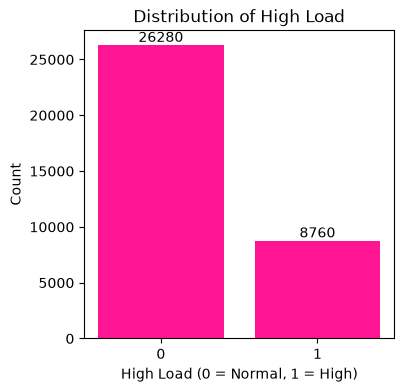

In [26]:
# Finding the 75th percentile
threshold = ds["Usage_kWh"].quantile(0.75)

#Creating a high_load feature
ds["High_load"]= ds["Usage_kWh"].apply(lambda x: 1 if x > threshold else 0)
#Counting the values
High_load = ds["High_load"].value_counts()  

#Displaying data
plt.figure(figsize=(4,4))
bars = plt.bar(High_load.index.astype(str), High_load.values,color="deeppink")
plt.bar_label(bars) 

plt.title("Distribution of High Load")
plt.xlabel("High Load (0 = Normal, 1 = High)")
plt.ylabel("Count")

plt.show()

### Interpretation:
- High_load feature was created using 75th percentile of Usage_kWh as threshold.
- Values above this threshold were labelled as **highload (1)** while remaining were labelled as **normal load (0)** .
- This feature helped us to find periods of high electricity usage.


## Detection of Outliers using IQR Method

In [27]:
#Inter Quartile Range
Q1 = ds["Usage_kWh"].quantile(0.25)        
Q3 = ds["Usage_kWh"].quantile(0.75)
IQR = Q3-Q1
print("InterQuartile Range:",IQR)

#Finding limits
lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR
print("Lower Limit:",lower_limit)
print("Upper Limit:",upper_limit)

#Finding Outliers
outliers = (ds["Usage_kWh"] < lower_limit) | (ds["Usage_kWh"] > upper_limit)
print("Number of Outliers:",outliers.sum())


InterQuartile Range: 48.037499999999994
Lower Limit: -68.85624999999999
Upper Limit: 123.29374999999999
Number of Outliers: 328


#### Interpretation:
IQR method was used to find the outliers in electricity usage. The values above the upper limit and below the lower limit were identified as outliers and it indicates the data have unusually high or low electricity usage.

### Boxplot for Outlier Detection

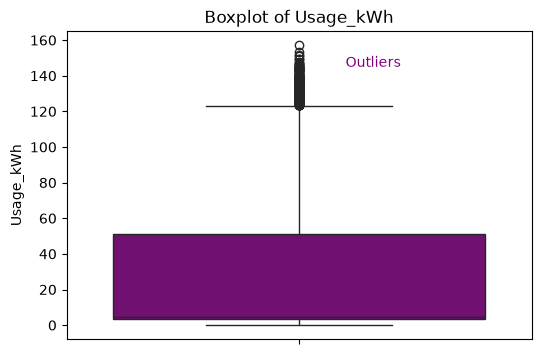

In [28]:
plt.figure(figsize=(6,4))
sns.boxplot(y=ds["Usage_kWh"], color="purple")
plt.title("Boxplot of Usage_kWh")
plt.text(0.1, 145, "Outliers", color="purple")
plt.show()

### Boxplot Interpretation:
- The boxplot shows the outliers and distriution of Usage_kWh. 
- The **purple box** shows the IQR (middle 50% of data) where most of the data lies. 
- The **black whiskers** represents the range of data, it is the extend beyond which outliers exists. 
- The **black dots** represents the outliers which majorly lies above the upper limit indicating an unusually higher electricity consumption. 
- No lower outliers are present because electricity consumption cannot be negative. 

## Correlation Heatmap

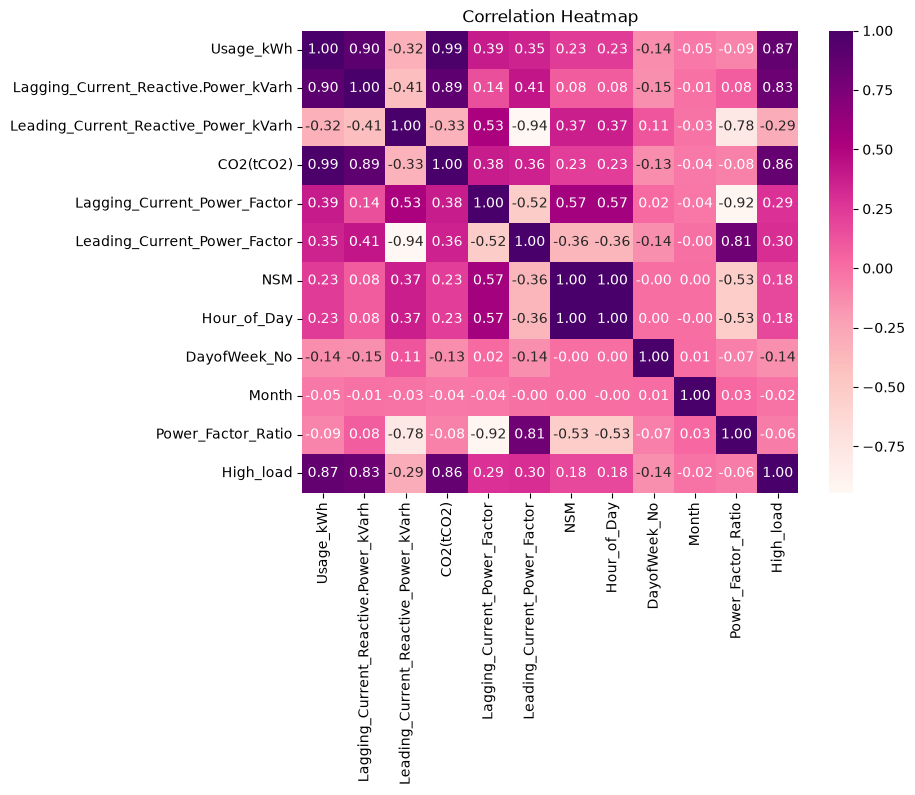

Features strongly Correlated with Usage_kWh:
CO2(tCO2)                               0.98818
Lagging_Current_Reactive.Power_kVarh    0.89615
Lagging_Current_Power_Factor            0.38596
Name: Usage_kWh, dtype: float64


In [29]:
#Select the numerical columns
numeric = ds.select_dtypes(include="number")

#Correlation Matrix
corr=numeric.corr()

#Heatmap 
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap="RdPu", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

#Top 3 features correlated to Usage_kWh
top3 = corr["Usage_kWh"].drop(["Usage_kWh","High_load"]).abs().sort_values(ascending=False).head(3)
print("Features strongly Correlated with Usage_kWh:")
print(top3)

### Interpretation 
- The correlation heatmap having a value closer to 1 or -1 indicates a strong correlation.
- With respect to Usage_kWh strongest correlation exists with C02 i.e **0.988**, indicating high energy consumption leads to high carbon emissions.
- Lagging_Current_Reactive_Power_kVarh shows a strong positive correlation i.e **0.90**, indicating that reactive power demand increases with energy usage.
- Lagging_Current_Power_Factor shows a moderate positive correlation i.e **0.385**, indicating power factor variations are somewhat associated with energy usage changes.
- Newly Engineered feature such as High_load shows strong correlation with Usage_kWh but as it is derived from Usage_kWh itself hence should not be included in correlation ranking as it may result in data leakage.

## Grouped Bar Chart

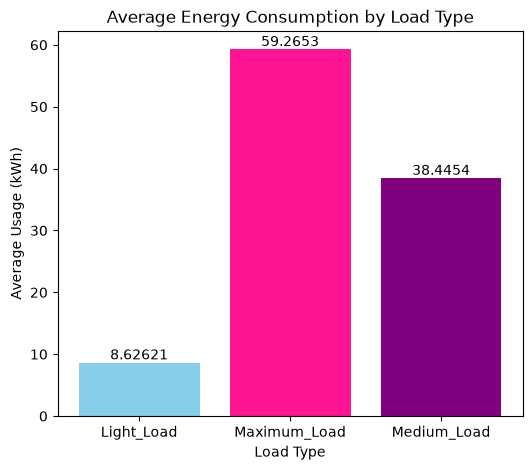

In [30]:
avg_load = ds.groupby("Load_Type")["Usage_kWh"].mean()
plt.figure(figsize=(6,5))
bars = plt.bar(avg_load.index,avg_load.values,color=["skyblue","deeppink","purple"])
plt.bar_label(bars) 
plt.title("Average Energy Consumption by Load Type")
plt.xlabel("Load Type")
plt.ylabel("Average Usage (kWh)")
plt.show()

#### Interpretation:
- Bar chart shows the average energy consumption for each load type.
- Maximum load type has highest average energy consumption indicating an increased electricity demand.
- This indicates that the Load type is directly related to the energy consumption level.

## Line Chart

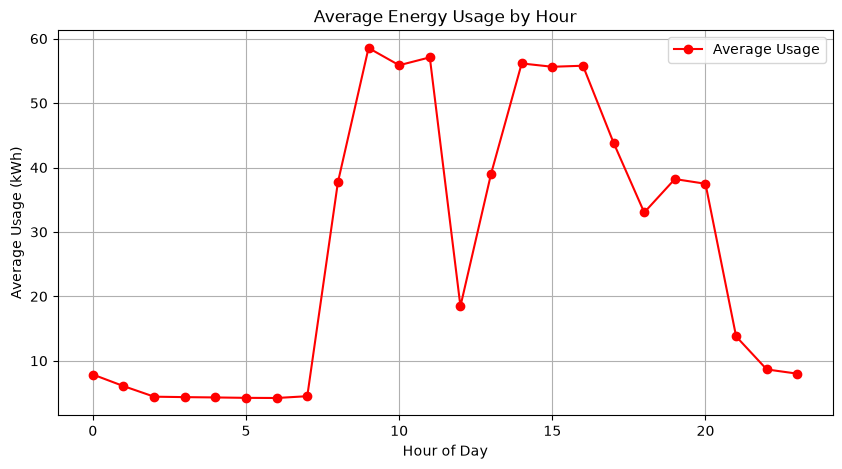

In [31]:
hourly_usage = ds.groupby("Hour_of_Day")["Usage_kWh"].mean()

plt.figure(figsize=(10,5))
plt.plot(hourly_usage.index,hourly_usage.values,marker="o",color="red", label="Average Usage")
plt.legend()

plt.title("Average Energy Usage by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Average Usage (kWh)")
plt.grid(True)
plt.show()

### Interpretation:
- The line chart shows the trend in Average energy consumption per hour.
- Across different hours the energy consumption changes, with peaks indicating high electricity demand.
- This chart indicates that time of day influences energy consumption behavior.

#### Saving the Dataset file with Engineered features

In [32]:
# Saving the Engineered dataset file for future use 
ds.to_excel( "C:/Users/Laptop Zone/OneDrive/Desktop/Steel_industry_engineered.xlsx",index=False)
print("Engineered dataset saved successfully!")

Engineered dataset saved successfully!


## EDA Summary

After performing Exploratory Data Analysis on the Steel Industry Energy Consumption dataset, it was observed that the data was clean and suitable for further analysis and modeling. The dataset contained **no missing values and duplicate records**. However, after creating the Power Factor Ratio feature, one missing value was introduced, which should be handled before model training. Additionally, the extracted Day of Week and Week status feature duplicated information already present in the dataset, creating redundancy.
Additional engineered features, including **Power Factor ratio** and **High load** were created to enrich the dataset. Using IQR method outliers were detected and visualized by **box plot**. Majorly outliers lie during the period of unusual high industrial activity.**Correlation analysis** revealed that features showing strong positive correlation with Usage_kWh are CO2, Lagging Current Reactive Power, and Lagging Current Power, indicating that variables increase together as production intensity rises. The **grouped bar chart** clearly shows an increase in energy usage from light load to maximum load, hence indicating that load type strongly influences electricity usage. The **hourly line chart** changes noticeably throughout the day, indicating that energy usage fluctuates according to industry's operations. 
An **interesting pattern** observed from bar and line chart was that energy usage is not uniform over time instead it follows a daily trend with reaching its higher average values during Maximum load periods, indicating a strong relationship between production activity and electricity consumption. 
Therefore, a possible **hypothesis** is that energy spikes are likely caused by increased manufacturing activities, when multiple high power machines are operating at the same time.